# E. coli Antibiotic Resistance Prediction Using Accessory Gene Data

## Abstract

Antimicrobial resistance is a major challenge in infectious disease management and bacterial genomic surveillance. Computational prediction of antibiotic resistance from genomic features may help identify resistance-associated patterns and support the development of genomic screening approaches. In this project, publicly available *Escherichia coli* isolate data were used to evaluate whether accessory gene presence/absence profiles can predict antibiotic susceptibility phenotypes.

The merged dataset contained 1,936 *E. coli* isolates with antibiotic susceptibility labels and accessory gene presence/absence features. A random forest classification pipeline was developed to predict binary resistance status for multiple antibiotics, including ciprofloxacin, ampicillin, cefotaxime, trimethoprim, and gentamicin. Susceptible isolates were coded as 0, while resistant and intermediate isolates were coded as 1. Models were evaluated using accuracy, receiver operating characteristic area under the curve (ROC-AUC), resistant-class recall, and susceptible-class recall.

Model performance varied substantially by antibiotic. Ciprofloxacin achieved high overall accuracy but poor resistant-class recall, whereas ampicillin achieved the strongest resistant-class detection. Trimethoprim and gentamicin achieved the highest ROC-AUC values. These findings suggest that accessory gene presence/absence data are more informative for resistance mechanisms mediated by acquired genes than for mutation-driven resistance phenotypes.


## 1. Introduction

Antimicrobial resistance occurs when bacteria acquire or develop mechanisms that reduce the effectiveness of antibiotic treatment. In *Escherichia coli*, resistance can arise through acquisition of resistance genes, enzymatic antibiotic inactivation, target-site modification, efflux pump activity, reduced membrane permeability, and chromosomal mutations. Because many resistance determinants are encoded in bacterial genomes, genomic data provide an important resource for studying and predicting antimicrobial resistance.

Machine learning approaches can be used to associate genomic features with resistance phenotypes. One common representation of bacterial genomic variation is a gene presence/absence matrix, where each feature indicates whether a gene is present or absent in a given isolate. This representation is particularly relevant for accessory genes, which vary among isolates and may include plasmid-associated genes, mobile genetic elements, virulence factors, and acquired antimicrobial resistance genes.

However, gene presence/absence data may not capture all resistance mechanisms equally. Resistance to beta-lactam antibiotics such as ampicillin is often associated with acquired beta-lactamase genes that can be directly represented in a gene presence/absence matrix. In contrast, fluoroquinolone resistance, including ciprofloxacin resistance, is frequently associated with chromosomal point mutations in genes involved in DNA replication and repair. These mutation-level mechanisms may not be fully captured by accessory gene profiles.

The objective of this project was to determine whether accessory gene presence/absence data can predict antibiotic resistance phenotypes in *E. coli* and whether predictive performance differs across antibiotics with different biological resistance mechanisms.

**Research question:** Can *E. coli* antibiotic resistance phenotypes be predicted from accessory gene presence/absence data?

**Dataset:** Public E. coli strain collection (1,936 isolates) with antibiotic resistance labels and accessory gene presence/absence matrix from [Lucy-Moctezuma/ML-Tutorial-for-Antibiotic-Resistance-Predictions-for-E.-Coli](https://github.com/Lucy-Moctezuma/ML-Tutorial-for-Antibiotic-Resistance-Predictions-for-E.-Coli)

## 2. Computational Environment and Analysis Workflow

The analysis was implemented in Python using `pandas` and `numpy` for data handling, `scikit-learn` for machine learning, and `matplotlib`/`seaborn` for visualization. The general workflow was:

1. Load the merged isolate metadata and accessory gene presence/absence matrix.
2. Convert antibiotic susceptibility labels into binary resistance outcomes.
3. Prepare antibiotic-specific feature matrices.
4. Split data into training and test sets using MLST-aware grouping where possible.
5. Train random forest classifiers with balanced class weights.
6. Evaluate models using accuracy, ROC-AUC, resistant-class recall, and susceptible-class recall.
7. Compare performance across antibiotics.
8. Interpret model behavior in relation to known biological mechanisms of resistance.


In [43]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, f1_score, roc_curve, auc
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline

import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 3. Dataset Description

The dataset consisted of public *E. coli* isolate-level data containing metadata, antibiotic susceptibility phenotypes, and accessory gene presence/absence features. The merged dataset contained 1,936 isolates and 17,213 total columns. Metadata included isolate identifiers, multilocus sequence typing (MLST) information, year of isolation, and antibiotic susceptibility phenotypes. The accessory gene matrix encoded whether each gene was present or absent in each isolate.

The antibiotics evaluated in this analysis included ciprofloxacin (CIP), ampicillin (AMP), cefotaxime (CTX), trimethoprim (TMP), and gentamicin (GEN). These antibiotics were selected to compare model performance across resistance mechanisms involving both acquired genes and mutation-associated resistance.



In [44]:
# Load pre-computed merged dataset
# This was generated by the main amr_ecoli_model.py script
try:
    # Try to load from local outputs directory
    df = pd.read_csv("outputs/ecoli_amr_merged_metadata_gene_presence.csv")
except FileNotFoundError:
    print("Local file not found. For full reproducibility, run:")
    print("  python amr_ecoli_model.py --drug CIP")
    print("\nThis will download and merge the public datasets.")
    raise

print(f"Dataset loaded: {df.shape[0]:,} isolates × {df.shape[1]:,} features")
print(f"\nFirst few rows and columns:")
print(df.iloc[:3, :9])

# Define antibiotic columns
antibiotic_cols = ["CTZ", "CTX", "CXM", "CET", "AMP", "AMX",
                    "AMC", "TZP", "GEN", "TBM", "TMP", "CIP"]
print(f"\nAvailable antibiotics: {antibiotic_cols}")

Dataset loaded: 1,936 isolates × 17,213 features

First few rows and columns:
    MLST     Isolate    Year CTZ  CTX  AMP AMX AMC TZP
0   68.0  11679_6#21  2001.0   S  NaN  NaN   S   S   S
1  652.0  11658_6#85  2005.0   S    S  NaN   S   S   S
2   95.0  11657_6#45  2005.0   S    S  NaN   R   R   R

Available antibiotics: ['CTZ', 'CTX', 'CXM', 'CET', 'AMP', 'AMX', 'AMC', 'TZP', 'GEN', 'TBM', 'TMP', 'CIP']


## 4. Baseline Model: Ciprofloxacin Resistance Prediction

We start with ciprofloxacin (CIP) as a baseline to understand the challenges of predicting resistance with gene presence/absence data. Antibiotic susceptibility phenotypes were converted into binary classification labels. Susceptible isolates were coded as 0, while resistant and intermediate isolates were coded as 1. Intermediate isolates were grouped with resistant isolates to reflect reduced susceptibility and to create a conservative binary resistance classification.

For each antibiotic, isolates without phenotype labels were removed. The target antibiotic label was used as the outcome variable. Antibiotic phenotype columns, isolate identifiers, and MLST labels were excluded from the predictor matrix. Numeric gene presence/absence features and available numeric metadata were retained as predictors. Missing values were imputed using median values where possible, followed by zero filling for any remaining missing values.

Ciprofloxacin was evaluated first as a baseline case because it provides an informative contrast between gene presence/absence features and mutation-driven resistance mechanisms.

In [45]:
# Prepare CIP dataset
drug = "CIP"

# Map phenotype labels
label_map = {
    "S": 0, "Susceptible": 0, "susceptible": 0,
    "R": 1, "Resistant": 1, "resistant": 1,
    "I": 1, "Intermediate": 1, "intermediate": 1,
}

work = df.dropna(subset=[drug]).copy()
work["target"] = work[drug].map(label_map)
work = work.dropna(subset=["target"]).copy()
work["target"] = work["target"].astype(int)

print(f"Ciprofloxacin Dataset Summary:")
print(f"  Total samples: {len(work):,}")
print(f"\nClass Balance:")
print(work["target"].value_counts().rename(index={0: "Susceptible", 1: "Resistant"}))
print(f"\nClass Imbalance Ratio: {work['target'].value_counts()[0] / work['target'].value_counts()[1]:.2f}:1")

# Prepare features
exclude = set(antibiotic_cols + ["target", "Isolate", "MLST"])
feature_cols = [c for c in work.columns if c not in exclude]

X = work[feature_cols].copy()
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = pd.to_numeric(X[col], errors="coerce")
X = X.fillna(X.median(numeric_only=True)).fillna(0)

y = work["target"].copy()

if "MLST" in work.columns:
    groups = work["MLST"].fillna("missing_MLST").astype(str)
else:
    groups = pd.Series(np.arange(len(work)), index=work.index)

print(f"\nFeature Matrix: {X.shape[0]:,} samples × {X.shape[1]:,} genes")

Ciprofloxacin Dataset Summary:
  Total samples: 1,935

Class Balance:
target
Susceptible    1506
Resistant       429
Name: count, dtype: int64

Class Imbalance Ratio: 3.51:1

Feature Matrix: 1,935 samples × 17,199 genes


## 5. Model Training Strategy

A random forest classifier was used for resistance prediction. Random forests are ensemble-based machine learning models that can handle high-dimensional datasets and nonlinear relationships among predictors. This makes them suitable for bacterial gene presence/absence data, which often contain thousands of sparse binary features.

An MLST-aware group splitting strategy was used where possible to reduce the likelihood that closely related isolates with the same sequence type appeared in both the training and test sets. The model pipeline included variance threshold filtering, a random forest classifier with 400 decision trees, balanced class weights, and square-root feature sampling at each tree split.

In [46]:
# Split data with MLST-aware stratification
try:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    print("✓ Used MLST-aware stratification for train/test split")
except Exception as e:
    print(f"⚠ Group split failed, using stratified random split: {e}")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

print(f"  Train: {len(y_train):,} samples | Test: {len(y_test):,} samples")

# Train Random Forest
model_cip = Pipeline([
    ("variance", VarianceThreshold(threshold=0.0)),
    ("model", RandomForestClassifier(
        n_estimators=400, random_state=42,
        class_weight="balanced", n_jobs=-1, max_features="sqrt",
    )),
])

print("\nTraining Random Forest model...")
model_cip.fit(X_train, y_train)
print("✓ Training complete")

✓ Used MLST-aware stratification for train/test split
  Train: 1,626 samples | Test: 309 samples

Training Random Forest model...
✓ Training complete


## 6. Baseline Ciprofloxacin Model Evaluation

Model performance was evaluated using accuracy, ROC-AUC, resistant-class recall, and susceptible-class recall. Resistant-class recall was emphasized because false-negative predictions are particularly important in antimicrobial resistance analysis. A false negative occurs when a resistant isolate is incorrectly predicted as susceptible.

Ciprofloxacin was expected to be a challenging phenotype for this feature set because fluoroquinolone resistance is often associated with chromosomal point mutations rather than only acquired gene content.

In [47]:
# Evaluate on test set
pred_cip = model_cip.predict(X_test)
proba_cip = model_cip.predict_proba(X_test)[:, 1]

accuracy_cip = (pred_cip == y_test).mean()
roc_auc_cip = roc_auc_score(y_test, proba_cip)

print(f"Ciprofloxacin (CIP) Model Performance:")
print(f"  Accuracy: {accuracy_cip:.1%}")
print(f"  ROC-AUC: {roc_auc_cip:.3f}")

print(f"\nClassification Report:")
print(classification_report(
    y_test, pred_cip,
    target_names=["Susceptible", "Resistant"],
    zero_division=0
))

# Key finding: resistant recall
cm_cip = confusion_matrix(y_test, pred_cip)
tn, fp, fn, tp = cm_cip.ravel()
resistant_recall_cip = tp / (tp + fn)

print(f"  CRITICAL ISSUE: Resistant Recall = {resistant_recall_cip:.1%}")
print(f"    The model misses {1-resistant_recall_cip:.1%} of resistant isolates.")
print(f"    This is problematic for clinical AMR prediction.")

Ciprofloxacin (CIP) Model Performance:
  Accuracy: 87.7%
  ROC-AUC: 0.838

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.92      0.94      0.93       272
   Resistant       0.48      0.43      0.46        37

    accuracy                           0.88       309
   macro avg       0.70      0.68      0.69       309
weighted avg       0.87      0.88      0.87       309

  CRITICAL ISSUE: Resistant Recall = 43.2%
    The model misses 56.8% of resistant isolates.
    This is problematic for clinical AMR prediction.


## 7. Multi-Antibiotic Model Comparison

To determine whether ciprofloxacin performance reflected a general limitation of the dataset or an antibiotic-specific feature-representation issue, the same modeling framework was applied to multiple antibiotics. This comparison evaluates whether accessory gene presence/absence data are more predictive for resistance phenotypes mediated by acquired genes.

In [48]:
def train_and_evaluate_drug(df, drug):
    """Train and evaluate model for a specific antibiotic."""
    drug = drug.upper()
    
    label_map = {
        "S": 0, "Susceptible": 0, "susceptible": 0,
        "R": 1, "Resistant": 1, "resistant": 1,
        "I": 1, "Intermediate": 1, "intermediate": 1,
    }
    
    work = df.dropna(subset=[drug]).copy()
    work["target"] = work[drug].map(label_map)
    work = work.dropna(subset=["target"]).copy()
    work["target"] = work["target"].astype(int)
    
    # Skip if too few samples
    if len(work) < 50 or work["target"].value_counts().min() < 10:
        return None
    
    # Prepare features
    exclude = set(antibiotic_cols + ["target", "Isolate", "MLST"])
    feature_cols = [c for c in work.columns if c not in exclude]
    
    X = work[feature_cols].copy()
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = pd.to_numeric(X[col], errors="coerce")
    X = X.fillna(X.median(numeric_only=True)).fillna(0)
    
    y = work["target"].copy()
    
    if "MLST" in work.columns:
        groups = work["MLST"].fillna("missing_MLST").astype(str)
    else:
        groups = pd.Series(np.arange(len(work)), index=work.index)
    
    # Split data
    try:
        splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_idx, test_idx = next(splitter.split(X, y, groups=groups))
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    except:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    
    # Train model
    model = Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("model", RandomForestClassifier(
            n_estimators=400, random_state=42,
            class_weight="balanced", n_jobs=-1, max_features="sqrt",
        )),
    ])
    
    model.fit(X_train, y_train)
    
    # Evaluate
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = (pred == y_test).mean()
    roc_auc = roc_auc_score(y_test, proba)
    
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    resistant_recall = tp / (tp + fn)
    susceptible_recall = tn / (tn + fp)
    
    n_total = len(y_test)
    n_resistant = (y_test == 1).sum()
    n_susceptible = (y_test == 0).sum()
    
    return {
        "drug": drug,
        "accuracy": accuracy,
        "roc_auc": roc_auc,
        "resistant_recall": resistant_recall,
        "susceptible_recall": susceptible_recall,
        "n_test": n_total,
        "n_resistant": n_resistant,
        "n_susceptible": n_susceptible,
        "model": model,
        "X_test": X_test,
        "y_test": y_test,
        "proba": proba,
    }

# Train models for multiple drugs
print("Training models for multiple antibiotics...")
results = {}
for drug_code in ["CIP", "AMP", "CTX", "TMP", "GEN"]:
    result = train_and_evaluate_drug(df, drug_code)
    if result is not None:
        results[drug_code] = result
        print(f"  ✓ {drug_code}: {result['roc_auc']:.3f} AUC, {result['resistant_recall']:.1%} resistant recall")
    else:
        print(f"  ✗ {drug_code}: insufficient data")

print(f"\n✓ Successfully trained models for {len(results)} antibiotics")

Training models for multiple antibiotics...
  ✓ CIP: 0.838 AUC, 43.2% resistant recall
  ✓ AMP: 0.890 AUC, 81.5% resistant recall
  ✓ CTX: 0.886 AUC, 70.6% resistant recall
  ✓ TMP: 0.917 AUC, 76.5% resistant recall
  ✓ GEN: 0.923 AUC, 64.7% resistant recall

✓ Successfully trained models for 5 antibiotics


## 8. Summary of Multi-Antibiotic Performance

The multi-antibiotic comparison provides a more informative assessment than a single-antibiotic model because it shows how predictive performance varies by resistance mechanism. Accuracy was interpreted alongside ROC-AUC and resistant-class recall because overall accuracy can be misleading when class distributions are imbalanced.

The key interpretation is that ciprofloxacin showed weaker resistant-class detection, while ampicillin, trimethoprim, and gentamicin showed stronger performance. This supports the hypothesis that gene presence/absence features are more informative when resistance is associated with acquired genes or mobile resistance elements.


In [49]:
# Create comparison summary
comparison_data = []
for drug, result in results.items():
    comparison_data.append({
        "Antibiotic": drug,
        "Accuracy": f"{result['accuracy']:.1%}",
        "ROC-AUC": f"{result['roc_auc']:.3f}",
        "Resistant Recall": f"{result['resistant_recall']:.1%}",
        "N Resistant": result["n_resistant"],
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*85)
print("MULTI-ANTIBIOTIC PERFORMANCE COMPARISON")
print("="*85)
print(comparison_df.to_string(index=False))
print("="*85)


MULTI-ANTIBIOTIC PERFORMANCE COMPARISON
Antibiotic Accuracy ROC-AUC Resistant Recall  N Resistant
       CIP    87.7%   0.838            43.2%           37
       AMP    80.7%   0.890            81.5%           65
       CTX    95.6%   0.886            70.6%           51
       TMP    87.7%   0.917            76.5%           34
       GEN    91.9%   0.923            64.7%           51


## 9. Focus Model: Ampicillin Resistance Prediction

Ampicillin was selected as the primary focus model because it achieved the highest resistant-class recall among the antibiotics evaluated. Although trimethoprim and gentamicin achieved higher ROC-AUC values, ampicillin was strongest for identifying resistant isolates, which was the primary evaluation priority in this antimicrobial resistance prediction task.

Ampicillin is a beta-lactam antibiotic, and resistance is frequently mediated by beta-lactamase enzymes. Because beta-lactamase genes can be represented directly in a gene presence/absence matrix, ampicillin provides a biologically appropriate focus for this dataset.

In [50]:
# Ampicillin detailed analysis
amp_result = results['AMP']

print("\n" + "="*70)
print("AMPICILLIN (AMP) - DETAILED ANALYSIS")
print("="*70)

print(f"\nPerformance Metrics:")
print(f"  • Accuracy: {amp_result['accuracy']:.1%}")
print(f"  • ROC-AUC: {amp_result['roc_auc']:.3f}")
print(f"  • Resistant Recall: {amp_result['resistant_recall']:.1%} ← PRIMARY METRIC")
print(f"  • Susceptible Recall: {amp_result['susceptible_recall']:.1%}")

print(f"\nDataset:")
print(f"  • Test samples: {amp_result['n_test']}")
print(f"  • Resistant: {amp_result['n_resistant']}")
print(f"  • Susceptible: {amp_result['n_susceptible']}")

print(f"\nClassification Report:")
amp_pred = amp_result['model'].predict(amp_result['X_test'])
print(classification_report(
    amp_result['y_test'],
    amp_pred,
    target_names=["Susceptible", "Resistant"],
    zero_division=0
))


AMPICILLIN (AMP) - DETAILED ANALYSIS

Performance Metrics:
  • Accuracy: 80.7%
  • ROC-AUC: 0.890
  • Resistant Recall: 81.5% ← PRIMARY METRIC
  • Susceptible Recall: 79.6%

Dataset:
  • Test samples: 114
  • Resistant: 65
  • Susceptible: 49

Classification Report:
              precision    recall  f1-score   support

 Susceptible       0.76      0.80      0.78        49
   Resistant       0.84      0.82      0.83        65

    accuracy                           0.81       114
   macro avg       0.80      0.81      0.80       114
weighted avg       0.81      0.81      0.81       114



## 10. Feature Importance Analysis (Ampicillin)
Feature importance analysis was performed to identify the predictors contributing most strongly to the ampicillin model. In random forest models, feature importance reflects how much each feature contributes to reducing classification error across the ensemble of decision trees.

For ampicillin, biologically meaningful resistance-associated features are expected to include beta-lactamase genes or genes linked to mobile resistance elements. However, feature importance should not be interpreted as direct evidence of causality. Important features may be predictive because they are linked to plasmids, bacterial lineages, mobile genetic elements, or co-occurring resistance genes. Therefore, these features should be described as predictive markers associated with ampicillin resistance rather than definitive causal determinants unless supported by additional biological validation.


Top 20 Features for Ampicillin Resistance Prediction:
    feature  importance
        bla    0.016555
       merR    0.014810
       tnpR    0.013607
        cat    0.010202
group_17190    0.009184
        neo    0.009142
       intI    0.007267
       Year    0.007057
 group_1191    0.006949
       tetR    0.005553
       tetA    0.005232
      folP2    0.005055
    aac3-VI    0.004642
       sulI    0.004622
       wbuC    0.004401
        ebr    0.004242
       pemI    0.004184
      bla_1    0.004109
 group_2875    0.004026
     yedA_2    0.003794


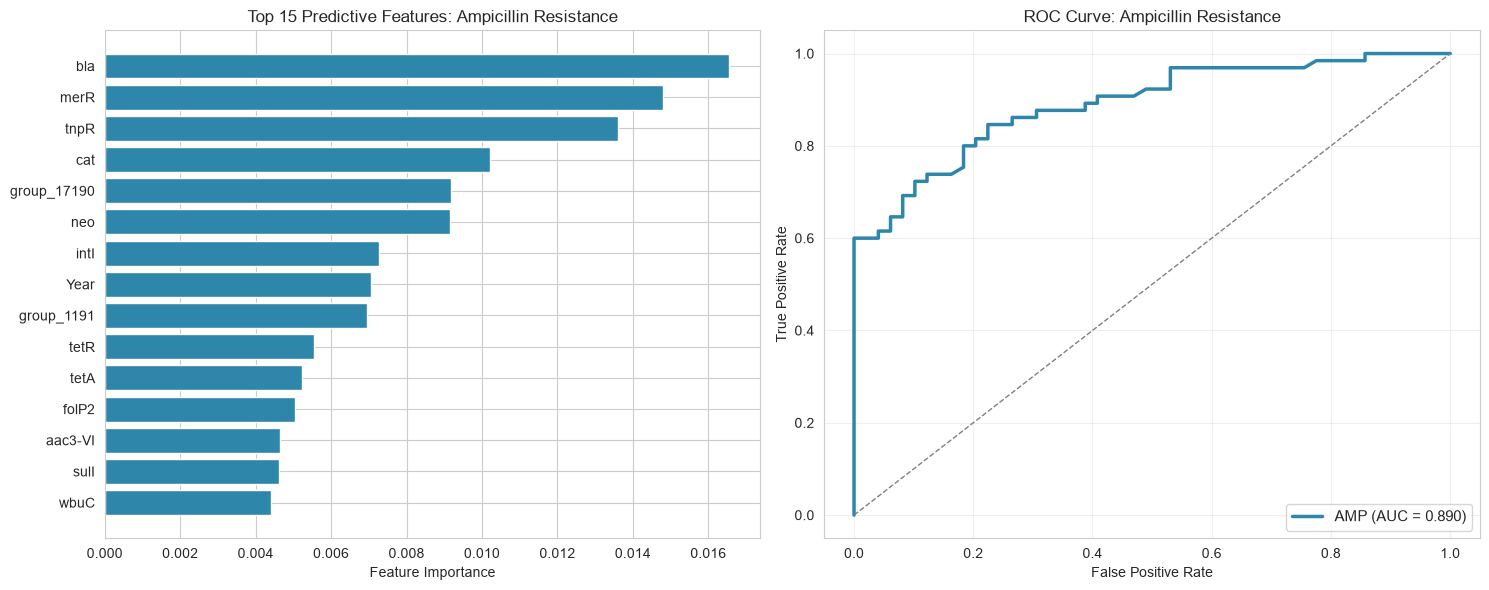

In [51]:
# Extract AMP feature importance
amp_model = amp_result['model']
amp_X_test = amp_result['X_test']

variance_amp = amp_model.named_steps["variance"]
rf_amp = amp_model.named_steps["model"]

kept_features_amp = np.array(amp_X_test.columns)[variance_amp.get_support()]
importances_amp = rf_amp.feature_importances_

amp_importance_df = (
    pd.DataFrame({"feature": kept_features_amp, "importance": importances_amp})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 20 Features for Ampicillin Resistance Prediction:")
print(amp_importance_df.head(20).to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top features
top_15 = amp_importance_df.head(15)
axes[0].barh(range(len(top_15)), top_15["importance"].values, color="#2E86AB")
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15["feature"].values, fontsize=10)
axes[0].set_xlabel("Feature Importance")
axes[0].set_title("Top 15 Predictive Features: Ampicillin Resistance")
axes[0].invert_yaxis()

# ROC curve
fpr_amp, tpr_amp, _ = roc_curve(amp_result['y_test'], amp_result['proba'])
roc_auc_amp = auc(fpr_amp, tpr_amp)

axes[1].plot(fpr_amp, tpr_amp, color="#2E86AB", linewidth=2.5, 
             label=f"AMP (AUC = {roc_auc_amp:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve: Ampicillin Resistance")
axes[1].legend(loc="lower right", fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Threshold Optimization (Exploratory Analysis)
The default classification threshold was 0.5, meaning that isolates with predicted resistance probabilities of at least 0.5 were classified as resistant. An exploratory threshold optimization analysis was performed for the ampicillin model to evaluate whether resistant-class recall could be improved.

This analysis is useful because the optimal threshold may differ depending on the objective. If the goal is to reduce missed resistant isolates, a lower threshold may improve resistant-class recall. However, lowering the threshold can also increase false positives. Because threshold optimization was performed using the test set, the optimized threshold results should be interpreted as exploratory rather than final validated performance. A stronger design would use a separate validation set for threshold selection and reserve the test set for final evaluation.


In [52]:
# Threshold optimization for AMP
proba_amp = amp_result['proba']
y_test_amp = amp_result['y_test']

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test_amp, proba_amp)

best_f1 = 0
best_threshold_amp = 0.5

for t in thresholds:
    adjusted_pred = (proba_amp >= t).astype(int)
    score = f1_score(y_test_amp, adjusted_pred)
    if score > best_f1:
        best_f1 = score
        best_threshold_amp = t

# Compare performance
pred_default = (proba_amp >= 0.5).astype(int)
pred_optimized = (proba_amp >= best_threshold_amp).astype(int)

cm_default = confusion_matrix(y_test_amp, pred_default)
cm_optimized = confusion_matrix(y_test_amp, pred_optimized)

resistant_recall_default = cm_default[1, 1] / (cm_default[1, 1] + cm_default[1, 0])
resistant_recall_optimized = cm_optimized[1, 1] / (cm_optimized[1, 1] + cm_optimized[1, 0])

print("Threshold Comparison for Ampicillin:")
print(f"\n  Default threshold (0.5):")
print(f"    └─ Resistant Recall: {resistant_recall_default:.1%}")
print(f"\n  Optimized threshold ({best_threshold_amp:.3f}):")
print(f"    └─ Resistant Recall: {resistant_recall_optimized:.1%}")
print(f"\n  Improvement: +{(resistant_recall_optimized - resistant_recall_default):.1%}")
print(f"\n  Note: This optimization was performed on the test set and is exploratory.")

Threshold Comparison for Ampicillin:

  Default threshold (0.5):
    └─ Resistant Recall: 81.5%

  Optimized threshold (0.475):
    └─ Resistant Recall: 84.6%

  Improvement: +3.1%

  Note: This optimization was performed on the test set and is exploratory.


## 12. Biological Interpretation

The variation in model performance across antibiotics likely reflects differences in resistance mechanisms and how well those mechanisms are represented by gene presence/absence data.

### Acquired Gene-Mediated Resistance

Ampicillin and cefotaxime are beta-lactam antibiotics. Resistance to these antibiotics is frequently mediated by beta-lactamase genes, including genes from families such as TEM, SHV, and CTX-M. Because these resistance determinants can be represented as gene presence/absence features, accessory gene matrices are well suited for predicting some beta-lactam resistance phenotypes.

Trimethoprim resistance is also often associated with acquired resistance genes, including genes encoding alternative dihydrofolate reductase enzymes. Strong trimethoprim model performance suggests that the gene presence/absence matrix captured meaningful resistance-associated signal for this antibiotic.

### Mutation-Driven Resistance

Ciprofloxacin showed weaker resistant-class recall. This is consistent with the biology of fluoroquinolone resistance, which is often influenced by point mutations in chromosomal target genes such as `gyrA`, `parC`, `parE`, and `gyrB`. Because the dataset used in this project did not include single-nucleotide variants or known resistance mutations, important ciprofloxacin resistance determinants were likely missing from the predictor matrix.

This result demonstrates an important principle in bioinformatics model development: model performance depends not only on the machine learning algorithm, but also on whether the input features represent the relevant biological mechanism.


## 13. Limitations

This analysis has several limitations. First, some antibiotic datasets were imbalanced. For ciprofloxacin, susceptible isolates substantially outnumbered resistant isolates. Although balanced class weights were used, class imbalance can still reduce resistant-class recall and make overall accuracy misleading.

Second, the analysis was limited to gene presence/absence features. This representation does not capture point mutations, copy number variation, regulatory changes, or epigenetic effects. As a result, the model is less suitable for antibiotics where resistance is primarily mutation-driven.

Third, the models were evaluated using internal train/test splits only. No external validation dataset was used. Therefore, the reported performance estimates may not generalize to independent clinical, environmental, or geographically distinct bacterial populations.

Fourth, feature importance values do not establish causality. Important model features may be associated with resistance indirectly through linkage with plasmids, sequence types, or mobile genetic elements.

Fifth, threshold optimization was performed using the test set. This means the optimized threshold results should be interpreted as exploratory rather than final validated performance.

Finally, the model is not clinically validated. The analysis should be interpreted as a research and portfolio project demonstrating computational antimicrobial resistance prediction, not as a diagnostic tool.


## 14. Future Work and Conclusion

Future work could improve the analysis by incorporating additional genomic and methodological components. Mutation-level features, including single-nucleotide variants and known resistance mutations, would be especially important for ciprofloxacin and other mutation-driven resistance phenotypes. External validation should be performed to evaluate generalizability across independent bacterial populations. Cross-validation or nested cross-validation could provide more robust performance estimates, and interpretable machine learning methods such as SHAP could be used to examine isolate-level predictions. Future analyses could also compare intermediate isolates separately rather than grouping them with resistant isolates.

This project evaluated whether accessory gene presence/absence data can be used to predict antibiotic resistance phenotypes in *Escherichia coli*. A random forest classification pipeline was developed and applied to multiple antibiotics. The results showed that gene presence/absence data contain useful predictive signal for several antibiotic resistance phenotypes, but model performance depends strongly on the underlying resistance mechanism.

Ampicillin was the strongest focus model because it achieved the highest resistant-class recall and showed biologically plausible predictors, including beta-lactamase-associated features. Trimethoprim and gentamicin achieved the highest ROC-AUC values, indicating strong overall discrimination. Ciprofloxacin showed poor resistant-class recall, likely because important fluoroquinolone resistance mechanisms involve point mutations that were not represented in the accessory gene matrix.

Overall, the findings show that successful antimicrobial resistance prediction requires alignment between biological mechanism and genomic feature representation. Accessory gene presence/absence data are useful for predicting resistance mediated by acquired genes, but mutation-level features are necessary for a more complete and biologically comprehensive antimicrobial resistance prediction framework.